# Train Personlab with custom dataset
<a target="_blank" href="https://colab.research.google.com/github/SonySemiconductorSolutions/aitrios-rpi-tutorials-ai-model-training/blob/main/notebooks/personlab-gauge/custom_personlab.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Observe, that this tutorial requires GPU when used with Colab. Enable GPU:

- Navigate to Edit→Notebook Settings
- Select T4 GPU from Hardware Accelerator

We will train a key-points model on an [open-source gauge dataset](https://universe.roboflow.com/alexander-jaworowski-rshsa/digital-gauge-klmhl/dataset/2). The two key-points are the start and end of the gauge meter. Since the start is in the center, we can with some calibration convert the angle into the value that the meter is showing. For an example see the detection results in the [dataset model page](https://universe.roboflow.com/alexander-jaworowski-rshsa/digital-gauge-klmhl/model/2)

This tutorial is using training tools from https://github.com/SonySemiconductorSolutions/aitrios-rpi-training-samples. Specifically tools termed "posenet" which are for training of a [Keras Personlab model](https://github.com/octiapp/KerasPersonLab).

Tutorial includes:
- Installation of training repo
- Dataset setup
- Training setup
- Training and quantization
- Inference and visualization
- Conversion
- Running the model on Raspberry Pi AI Camera


In [ ]:
# Test that we are running correct Colab runtime type
# If error, change Colab runtime to 2025.07
import sys
v = sys.version_info
assert v.major == 3 and v.minor == 11, "Python version must be 3.11"

# Installation
We start by cloning the training repo and install the package imx500_zoo. However, since we are working in Colab, we do not install the dependencies in pyproject.yaml (--no-deps). Instead, in the next cell, we will install a somewhat modified set of dependencies that have been tested in Colab.

In addition to the packages needed for training, we also install:
- Application Module Library (modlib) for visualization
- the converter tool, imx500-converter
- dataset loader from Roboflow

__OBSERVE 1__: When running through Colab, you have to restart the session after the installations in the next code block.

__OBSERVE 2__: In Colab you will get a message such as `ERROR: pip's dependency resolver ...`. You can ignore the error and continue to run the notebook (after having restarted the Colab session).

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # clone repo
    !git clone --depth 1 https://github.com/SonySemiconductorSolutions/aitrios-rpi-training-samples; \
    
    
    # install imx500_zoo (without deps)
    !cd aitrios-rpi-training-samples && pip install --no-deps -e .
    !pip show imx500_zoo
    
    # install nanodet repo (required in order to use the training repo)
    !cd aitrios-rpi-training-samples/third_party/nanodet/nanodet && pip install -e .
    
    # Install training deps that works with Colab.
    # Install aitrios-rpi-application-module-library (modlib) for inference and visualization
    # Install imx500 converter so that we can convert the keras model to imx500 format.
    # Install roboflow for dataset handling
    !pip install \
    model-compression-toolkit==2.1.0 \
    torch==2.1.2 \
    torchvision==0.16.2 \
    torchinfo==1.8.0 \
    lightning==2.1.3 \
    onnx==1.14.1 \
    onnxruntime==1.15.1 \
    onnxruntime-extensions==0.10.1 \
    tensorflow~=2.15.0 \
    tensorflow-model-optimization==0.7.5 \
    tensorflow-addons==0.23.0 \
    pycocotools==2.0.7 \
    albumentations==1.3.1 \
    tabulate==0.9.0 \
    tqdm~=4.67.0 \
    "numpy<2.0" \
    safetensors~=0.5.0 \
    imx500-converter[tf] \
    git+https://github.com/SonySemiconductorSolutions/aitrios-rpi-application-module-library.git \
    roboflow
else:
    print("Not Colab - assuming container has necessary dependencies installed")

In [ ]:
%%bash
cd aitrios-rpi-training-samples/
git apply - <<'EOF'
diff --git a/src/imx500_zoo/quantizers/mct_tflite.py b/src/imx500_zoo/quantizers/mct_tflite.py
index e1f8366..141dae8 100644
--- a/src/imx500_zoo/quantizers/mct_tflite.py
+++ b/src/imx500_zoo/quantizers/mct_tflite.py
@@ -186,6 +186,7 @@ class MCTWorkFlow(YamlConfigParser):
                             mct_keras_model_path,
                         )
                         print(f"write quantized output: {mct_int8_cpu_model_path}")
+                        return

                         logs = tflite_inference.keypoint_inference(
                             mct_int8_cpu_model_path,
EOF

In [ ]:
"""
Perform initial checks in order to continue

if you get:
    RecursionError: maximum recursion depth exceeded while getting the repr of an object

then restart the session and re-run the cell
"""
import os
import shutil
import tensorflow as tf
import torch
import numpy as np
import modlib
import nanodet
import model_compression_toolkit
import roboflow

assert '2.15' in tf.__version__, print(tf.__version__)
assert '2.1.' in torch.__version__, print(torch.__version__)
assert '1' in np.__version__[0], print(np.__version__)

gpus = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available for TensorFlow: ", len(gpus))
if len(gpus)<1:
    print(f"WARNING: Found no GPU, running with GPU is highly recommended")

In [ ]:
# Converter requires java
import os
import re
import subprocess

def install_java(package: str = 'openjdk-17-jdk', version: int = 17) -> bool:
    try:
        result = subprocess.run(['java', '--version'], check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        version_output = result.stdout.splitlines()[0]
        match = re.search(r'(\d+)\.(\d+)\.(\d+)', version_output)  # Match version in form major.minor.patch
        print(f"Found Java version: {match.group(0)}")
        if match:
            major_version = int(match.group(1))
            if major_version == version:
                return True
            else:
                print(f"Java {version} is not installed. Installing correct version...")
    except (subprocess.CalledProcessError, FileNotFoundError) as e:
        print(f"Java not installed. Installing...")

    try:
        is_root = os.geteuid() == 0
        prefix = [] if is_root else ['sudo']
        with open(os.devnull, 'w') as devnull:
            subprocess.run(prefix + ['apt', 'update'], check=True, stdout=devnull, stderr=devnull)
            subprocess.run(prefix + ['apt', 'install', '-y', package], check=True, stdout=devnull, stderr=devnull)
        return True
    except subprocess.CalledProcessError as e:
        print(f"Installation error: {e}")
        return False

if install_java():
    print(f'Java installed')
else:
    print(f'Java missing and installation failed')

# Settings
First we seup some global variables to be used in the notebook. Rerun the cell below if you need to re-initialize the settings, for example if jupyter kernel needs restart.

In [ ]:
# Settings
DATASET_NAME = 'digital-gauge-2'
DATASET_PATH = f'aitrios-rpi-training-samples/samples/data/DigitalGaugePosenet'
QUANTIZED_MODEL = "aitrios-rpi-training-samples/samples/model/posenet_digitalgauge/posenet_digitalgauge_quantized.keras"
SHARED = "tutorial"

# Dataset
To authenticate with the Roboflow API, you need an API key. Here we will obtain the API key using Roboflow token issuance flow, https://docs.roboflow.com/api-reference/authentication#token-issuance-flow.

In the next cell you will be asked to visit an url to get the authentication token.
Once you have copied the token, paste in the input field on top of the VS Code editor.

In [ ]:
from pathlib import Path
import roboflow

def move_dataset():
    !mkdir -p {DATASET_PATH}
    !mv {DATASET_NAME} {DATASET_PATH}
    print(f"Moved dataset")

# Check if dataset already exists, if not download it and move to correct location
if Path(f'{DATASET_NAME}').exists():
    print(f"Dataset already downloaded: {DATASET_NAME}")
    move_dataset()
else:
    if Path(f'{DATASET_PATH}/{DATASET_NAME}').exists():
        print(f"Dataset already in correct location: {DATASET_PATH}/{DATASET_NAME}")
    else:
        print(f"Downloading dataset: {DATASET_NAME}")
        # Get token - follow instructions
        roboflow.login()
        
        # Download dataset
        rf = roboflow.Roboflow()
        project = rf.workspace("alexander-jaworowski-rshsa").project("digital-gauge-klmhl")
        version = project.version(2)
        dataset = version.download("coco")    
        move_dataset()
!ls {DATASET_PATH}/{DATASET_NAME}

In [ ]:
assert Path(f'{DATASET_PATH}/{DATASET_NAME}/train/_annotations.coco.json').exists()
assert Path(f'{DATASET_PATH}/{DATASET_NAME}/valid/_annotations.coco.json').exists()

# Training configs
We will create two config files to train the model with our dataset. Main reference for this is the [training docs](https://github.com/SonySemiconductorSolutions/aitrios-rpi-training-samples/blob/main/docs/Posenet_NewDataset.md).

## posenet_digitalgauge.ini
This is the primary config file. Note that we have updated:
* NUM_CLASSES, our model has 2 key-points
* BATCH_SIZE, set to 6 but can be adjusted
* NUM_EPOCHS, high value, observe that the trainer has early-stopping, i.e. will stop when model training does not improve after a certain amount of epochs. For this dataset, ~75 epochs are needed to get some proper key-point detections
* CONFIG, we have a custom model config file, see next

## posenet_digitalgauge.json
This config file is used to configure the model. The main parameters:
* NUM_KP, we have 2, start (origin) and end of gauge meter
* KEYPOINTS, the names come from the dataset json file
* EDGES, very simple in our case
* PEAK_THRESH, this threshold might need adjustments for another dataset
* kpt_oks_sigmas: same number as NUM_KP and all values equal and set to 1/NUM_KP
* PATH, path to the dataset files
* CONF_MAP_KEY, first element of KEYPOINTS

## Comments for a 3-points dataset
Another possibility is that the gauge meter is annotated with three key-points. Many meters also extend somewhat to the other side of the center point. For such a situation the config parameters would change to:
* NUM_CLASSES, 3
* NUM_KP, 3
* KEYPOINTS, 3 string values corresponding to the key-point names in the dataset
* EDGES, [(0, 1), (1, 2)]
* NUM_EDGES, 2
* kpt_oks_sigmas, [0.33, 0.33, 0.33]


In [ ]:
%%bash
touch aitrios-rpi-training-samples/samples/posenet_digitalgauge.ini
cat <<EOF > aitrios-rpi-training-samples/samples/posenet_digitalgauge.ini
[SOLUTION]
FRAMEWORK = keras
RETRAIN = True
VALIDATE = True

[MODEL]
NAME = Posenet
PRE_TRAIN = False
INPUT_SIZE = [353, 481]
NUM_CLASSES = 2

[DATASET]
NAME = DefaultPosenet

[TRAINER]
NAME = PosenetTrainer
BATCH_SIZE = 6
NUM_EPOCHS = 1000
LEARNING_RATE = 0.0005
CONFIG = ./config/posenet_digitalgauge.json

[QUANTIZER]
NAME = MctTflite

[VALIDATOR]
NAME = KerasPosenetValidator
EOF

In [ ]:
%%bash
touch aitrios-rpi-training-samples/samples/config/posenet_digitalgauge.json
cat <<EOF > aitrios-rpi-training-samples/samples/config/posenet_digitalgauge.json
{
    "DATASET": {
        "TYPE": "DIGITALGAUGE",
        "NUM_KP": 2,
        "KEYPOINTS": [
            "start",
            "end"
        ],
        "KEYPOINTS_DICT": {
            "0": "start",
            "1": "end"
        },
        "EDGES": [
            [0, 1]
        ],
        "NORM_FACTOR": 256.0,
        "KP_RADIUS": 32,
        "PEAK_THRESH": 0.004,
        "OKS_THRESH": 0.5,
        "kpt_oks_sigmas": [
            0.5,
            0.5
        ],
        "NMS_THRESH": 32
    },
    "TRAINING": {
        "OUTPUT_STRIDE": 16,
        "LOSS_WEIGHTS": {
            "heatmap": 4,
            "short": 1,
            "mid": 0.25
        },
        "MULTIPROCESSING_FLAG": "True",
        "lr_decay_steps": 100,
        "lr_decay_rate": 0.95,
        "earlystop_patience": 75,
        "GPU_ID": 0
    },
    "PATH": {
        "ANNO_FILE_TRAIN": "data/DigitalGaugePosenet/digital-gauge-2/train/_annotations.coco.json",
        "IMG_DIR_TRAIN":   "data/DigitalGaugePosenet/digital-gauge-2/train",
        "ANNO_FILE_VAL":   "data/DigitalGaugePosenet/digital-gauge-2/valid/_annotations.coco.json",
        "IMG_DIR_VAL":     "data/DigitalGaugePosenet/digital-gauge-2/valid",
        "ANNO_FILE_TEST":  "data/DigitalGaugePosenet/digital-gauge-2/valid/_annotations.coco.json",
        "IMG_DIR_TEST":    "data/DigitalGaugePosenet/digital-gauge-2/valid"
    },
    "VISUALISE": {
        "CONF_MAP_KEY": "start"
    }
}
EOF

In [ ]:
# Helper: updates the ini file params
import configparser
import os

def modify_config(retrain=None, validate=None, num_epochs=None, config_path="aitrios-rpi-training-samples/samples/posenet_digitalgauge.ini"):
    if not os.path.exists(config_path):
        print(f"Config file not found: {config_path}")
        return

    config = configparser.RawConfigParser()
    config.optionxform = str  # preserve key case
    config.read(config_path)

    # Show current values (safely)
    current_retrain = config['SOLUTION'].get('RETRAIN', 'Not set')
    current_validate = config['SOLUTION'].get('VALIDATE', 'Not set')
    current_epochs = config['TRAINER'].get('NUM_EPOCHS', 'Not set')
    print(f"Current: RETRAIN={current_retrain}, VALIDATE={current_validate}, NUM_EPOCHS={current_epochs}")

    # Modify if provided
    if retrain is not None:
        config['SOLUTION']['RETRAIN'] = str(retrain)
    if validate is not None:
        config['SOLUTION']['VALIDATE'] = str(validate)
    if num_epochs is not None:
        config['TRAINER']['NUM_EPOCHS'] = str(num_epochs)

    # Save
    with open(config_path, 'w') as f:
        config.write(f)

    print(f"Updated: RETRAIN={config['SOLUTION']['RETRAIN']}, VALIDATE={config['SOLUTION']['VALIDATE']}, NUM_EPOCHS={config['TRAINER']['NUM_EPOCHS']}" )

# Training and Quantization
Now we are ready to train the model.

* num_epochs is set to a fairly low value initially that does not give the best results but still detects the gauge meter. For good detection results, set this value to 1000. Training will end using early-stopping when learning stops to improve.

In [ ]:
%%bash
cd aitrios-rpi-training-samples/
git apply - <<'EOF'
diff --git a/src/imx500_zoo/quantizers/mct_tflite.py b/src/imx500_zoo/quantizers/mct_tflite.py
index e1f8366..141dae8 100644
--- a/src/imx500_zoo/quantizers/mct_tflite.py
+++ b/src/imx500_zoo/quantizers/mct_tflite.py
@@ -186,6 +186,7 @@ class MCTWorkFlow(YamlConfigParser):
                             mct_keras_model_path,
                         )
                         print(f"write quantized output: {mct_int8_cpu_model_path}")
+                        return

                         logs = tflite_inference.keypoint_inference(
                             mct_int8_cpu_model_path,
EOF

In [ ]:
# train and quantize
import os
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
modify_config(retrain=True, validate=False, num_epochs=75)
!cd aitrios-rpi-training-samples/samples && imx500_zoo posenet_digitalgauge.ini

In [ ]:
assert os.path.exists(QUANTIZED_MODEL), f"Quantized file not found"

In [ ]:
""" Test that model_compression_toolkit (mct) still can be loaded after training

If mct fails to load:
- restart kernel
- reload settings code cell in the beginning of the notebook
"""
import importlib

module = "model_compression_toolkit"
try:
    importlib.import_module(module)
except Exception as e:
    print(f"failed import: {module} -> {e}")
    raise AssertionError(f"failed import: {module}")

# Inference and visualization with [Application Module Library](https://github.com/SonySemiconductorSolutions/aitrios-rpi-application-module-library)
Application Module Library (modlib) is an SDK designed to simplify and streamline the process of creating end-to-end applications for the IMX500 vision sensor, for example [Raspberry Pi AI camera](https://www.raspberrypi.com/documentation/accessories/ai-camera.html). The library also provides classes to visualize detections using Keras interpreter for inference, i.e. running inference without the sensor.

## Visualization app
The following code provides functions to visualize the model. It can be used in a Jupyter notebook to run inference on images and also to run on a Raspberry Pi with an AI Camera.

First we will use it to test our trained quantized model on validation images from the dataset.

Later, we will copy the code to a Raspberry Pi and test the model using the AI camera.

__OBSERVE:__ If you have trained with too few epochs, then you will see the message `No detections` for some of the images.  

In [ ]:
"""visualize.py"""
from datetime import datetime
import json
import os
from pathlib import Path
from typing import List
import shutil

import cv2
import numpy as np

from modlib.devices import AiCamera, KerasInterpreter
from modlib.devices.sources import Images
from modlib.apps import Annotator
from modlib.models import COLOR_FORMAT, Model, MODEL_TYPE
from modlib.models.results import Poses
from modlib.models.post_processors import pp_personlab

# When running on RPi with AI Camera
MODEL_PACKED =  Path.home() / Path("models/personlab/digital-gauge/pack/network.rpk")
CONFIG_PATH = Path.home() / Path("models/personlab/digital-gauge/posenet_digitalgauge.json")

class Personlab(Model):
    def __init__(self, weights, config, model_type=MODEL_TYPE.RPK_PACKAGED, is_quantized: bool = True):
        print(f"Using model: {weights}")
        super().__init__(
            model_file=weights,
            model_type=model_type,
            color_format=COLOR_FORMAT.RGB,
            preserve_aspect_ratio=False,
        )

        # Load json dataset info
        ds = config["DATASET"]

        self.num_kp = ds["NUM_KP"]
        self.edges = [tuple(edge) for edge in ds["EDGES"]]
        self.peak_thresh = ds["PEAK_THRESH"]
        self.nms_thresh = ds["NMS_THRESH"]
        self.kp_radius = ds["KP_RADIUS"]

        self.in_width = 481
        self.in_height = 353
        self.is_quantized = is_quantized

    def pre_process(self, img):
        img = cv2.resize(img, (self.in_width, self.in_height), interpolation=cv2.INTER_AREA)
        in_tensor = img / 256.0
        in_tensor = np.expand_dims(in_tensor, axis=0)
        return (img, in_tensor)

    def post_process(self, output_tensors: List[np.ndarray]) -> Poses:
        return pp_personlab(
            output_tensors,
            num_keypoints=self.num_kp,
            edges=self.edges,
            peak_threshold=self.peak_thresh,
            nms_threshold=self.nms_thresh,
            kp_radius=self.kp_radius,
        )

class MyKerasInterpreter(KerasInterpreter):
    def __init__(self, source, headless=False, timeout=None):
        super().__init__(source=source, headless=headless, timeout=timeout)

    @staticmethod
    def load_tf_keras_model(model: Model):
        """
        Loads a keras model file using tensorflow or model_compression_toolkit (if is_quantized is True).
        Requires tensorflow and model_compression_toolkit to be installed.

        Raises:
            ImportError: When loading the model fails due to missing dependencies.
        """
        model_path = model.model_file
        is_quantized = model.is_quantized

        try:
            print(f"Loading model: {model_path}, is_quantized: {is_quantized}")
            if is_quantized:
                import model_compression_toolkit as mct
                return mct.keras_load_quantized_model(model_path)
            else:
                import tensorflow as tf
                return tf.keras.models.load_model(model_path)
        except ImportError as e:
            raise ImportError(f"Failed to import model_compression_toolkit or tensorflow: {e}")
        except Exception as e:
            raise RuntimeError(f"Failed to load keras model: {e}")

    def deploy(self, model: Model):
        """
        Custom deploy method for KerasInterpreter.
        """
        print(f"[MyKerasInterpreter] Deploying model: {model.model_file}, {model.model_type}")
        if model.model_file is None:
            raise FileNotFoundError("Model file not found. Please provide a valid model file.")
        if not model.model_file.lower().endswith((".keras")):
            raise TypeError("Model file must be a Keras model file (.keras)")
        if not model.model_type == MODEL_TYPE.KERAS:
            raise TypeError("Model type must be Keras.")

        # Require model to have pre_process method
        if not hasattr(model, "pre_process"):
            raise AttributeError("Model must have a pre_process method to use MyKerasInterpreter.")

        self.model = model  # NOTE: personlab model has been modified to have is_quantized attribute
        self.keras_model = self.load_tf_keras_model(self.model)

def frame2image(img, output_dir="saved_images"):
    """Save the frame image with timestamp and gauge value."""
    # Generate timestamp for unique filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")[:-3]  # Include milliseconds

    # Create filename
    filename = f"gauge_{timestamp}.jpg"
    filepath = os.path.join(output_dir, filename)

    # Save the image
    cv2.imwrite(filepath, img)
    print(f"Saved image: {filepath}")

    return filepath

def visualize(
    model_file,
    config_path,
    is_quantized=True,
    images=None,
    output_dir=None,
    threshold=0.004,
    save_image=False,
    debug=False):

    # Check files
    if not Path(model_file).exists():
        raise FileNotFoundError(f"Model file not found: {model_file}")
    if not Path(config_path).exists():
        raise FileNotFoundError(f"Config file not found: {config_path}")

    # Load JSON
    config_json = json.loads(Path(config_path).read_text())
    ds = config_json["DATASET"]

    num_kp = ds["NUM_KP"]
    edges = [tuple(edge) for edge in ds["EDGES"]]

    # When we use keras model, we use MyKerasInterpreter and pre-recorded images as source
    if ".keras" in str(model_file):
        src = Images(images)
        device = MyKerasInterpreter(source=src)
        model = Personlab(
            weights=model_file,
            config=config_json,
            model_type=MODEL_TYPE.KERAS,
            is_quantized=is_quantized)
    else:
        device = AiCamera()
        model = Personlab(
            weights=model_file,
            config=config_json)

    device.deploy(model)

    annotator = Annotator()

    # Create output directory if it doesn't exist. Re-create existing directory
    if output_dir:
        if os.path.exists(output_dir):
            shutil.rmtree(output_dir)
        os.makedirs(output_dir)

    with device as stream:
        for frame in stream:
            if frame.detections.n_detections == 0:
                if save_image:
                    frame2image(frame.image)  # Save with value 0 for no detections
                else:
                    frame.display()
                if debug:
                    print("No detections")
                continue

            # apply filter
            frame.detections = frame.detections[np.min(frame.detections.keypoint_scores, axis=1) > threshold]
            if frame.detections.n_detections == 0:
                if save_image:
                    frame2image(frame.image)  # Save with value 0 for no detections after filter
                else:
                    frame.display()
                if debug:
                    print("No detections after filter")
                continue

            annotator.annotate_keypoints(
                frame,
                frame.detections,
                num_keypoints=num_kp,
                skeleton=edges,
                keypoint_score_threshold=threshold
            )

            if save_image:
                frame2image(frame.image)
            else:
                frame.display()

# This is executed automatically on RPi
if Path.home() == Path('/home/pi'):
    visualize(
        MODEL_PACKED,
        CONFIG_PATH)

In [ ]:
""" Run visualization on validation images

- Observe, running with the default number of epochs for the tutorial (75) it might be that some keypoints are not detected.
- Increase the number of epochs for better results.
"""
config_path =  Path.cwd() / Path("aitrios-rpi-training-samples/samples/config/posenet_digitalgauge.json")
validation_images_folder = Path.cwd() / Path(DATASET_PATH) / Path(DATASET_NAME) / Path("valid")
output_dir = Path.cwd() / Path("saved_images")
visualize(
    QUANTIZED_MODEL,
    config_path,
    images=validation_images_folder,
    output_dir=output_dir,
    save_image=True,
    debug=True)

In [ ]:
# Display results
import os
from PIL import Image
from IPython.display import display

# Folder containing images
folder_path = output_dir

# List image files
image_files = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
])
assert len(image_files) > 0, "No annotated files from keras interpreter"

# Display images
for file_name in image_files:
    img_path = os.path.join(folder_path, file_name)
    img = Image.open(img_path)
    display(img)

# Conversion
For details see
* [Raspberry Pi Documentation](https://www.raspberrypi.com/documentation/accessories/ai-camera.html#conversion)
* [Sony IMX500 Converter documentation](https://developer.aitrios.sony-semicon.com/en/raspberrypi-ai-camera/documentation/imx500-converter)

In [ ]:
!imxconv-tf -i {QUANTIZED_MODEL} -o converted --overwrite-output

In [ ]:
"""
Expected output from converter:

dnnParams.xml		 nanodet-quant-ppe_MemoryReport.json
nanodet-quant-ppe.pbtxt  packerOut.zip
"""
!ls converted
assert os.path.exists("converted/packerOut.zip"), f"Converted file not found"

# Copy converted files to tutorial/converted for easy access
!mkdir -p {SHARED}
!cp -r converted {SHARED}/
!ls {SHARED}/converted
assert os.path.exists(f"{SHARED}/converted/packerOut.zip"), f"Converted file not found"
print(f"Converted files copied to {SHARED}/converted")

In [ ]:
# Copy quantized model to tutorial/model for easy access
!mkdir -p {SHARED}
!cp {QUANTIZED_MODEL} {SHARED}/
!ls {SHARED}
assert os.path.exists(f"{SHARED}/posenet_digitalgauge_quantized.keras"), f"Quantized model not found: {SHARED}/posenet_digitalgauge_quantized.keras"
print(f"Quantized model copied: {SHARED}")

# Running the model on Raspberry Pi AI Camera
__OBSERVE__: First, save the quantized model and the output from the conversion to your local machine. For packaging you will need the `packerOut.zip` file.

Next step is to package the model for IMX500, see [Raspberry Pi Documentation](https://www.raspberrypi.com/documentation/accessories/ai-camera.html#packaging)

## Inference on Raspberry Pi
* Copy the visualization code from the cell above to `/home/pi/work/visualize.py`
* Install modlib on the Raspberry Pi, see [modlib](https://github.com/SonySemiconductorSolutions/aitrios-rpi-application-module-library)
* `visualize.py` expects that the packaged model and the configuration file is saved in certain folders, see variables:
```
  MODEL_PACKED
  CONFIG_PATH
```
* Copy some images from the validation dataset over to the Pi. Open any of the images and point the camera at the image.
* Run the application from the terminal:
```
  python3 visualize.py
```
* Adjust the camera orientation until you see the key-points detection overlayed on the application window.

The image below is a screenshot from the Pi. On the right we are displaying one of the validation images. The camera has been oriented to watch that part of the monitor. On the upper left we see the application window (started by visualize.py). It shows the camera view with annotated key-points detection as a yellow line on-top the gauge meter. On the lower left we see the terminal window from where the application visualize.py was started.

<p align="center">
  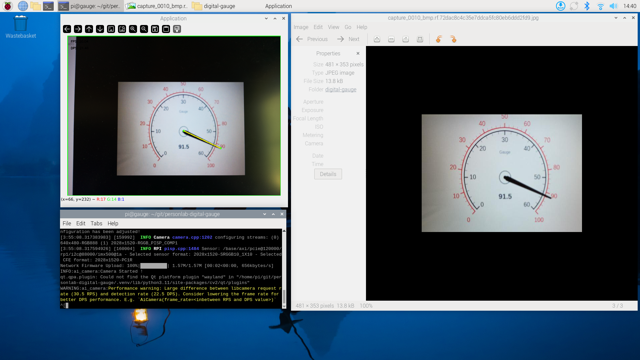
</p>